In [1]:
import healpy as hp 
import libpysal
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from AstroPySal import AstroPySal
from esda.moran import Moran, Moran_BV, Moran_Local, Moran_Local_BV
from matplotlib.colors import BoundaryNorm, ListedColormap

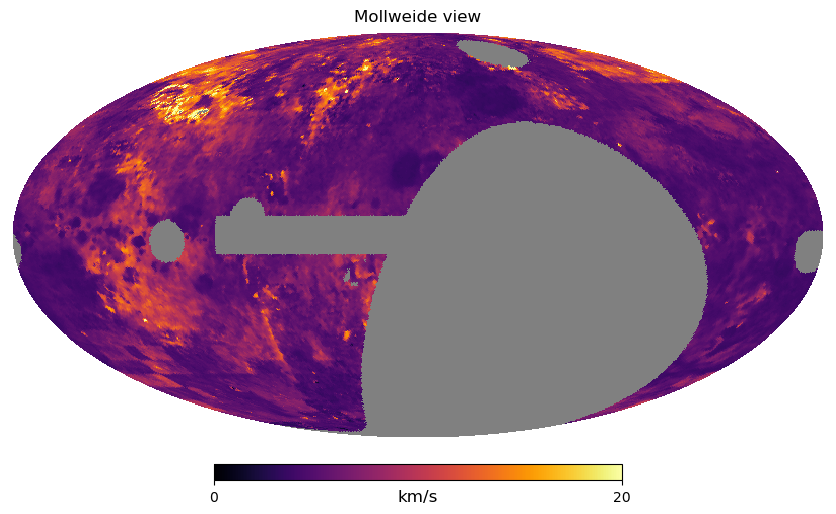

In [2]:
fn1 = "/mnt/extra/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M0_gal.hpx.fits"
fn2 = "/mnt/extra/ResearchSummer26/Code/AstroPySal/whamm2_healpix.fits"

dragDatM0 = fits.getdata(fn1)
whamDatm2 = hp.read_map(fn2)

#match footprints 
nside       = 128 
nPix        = hp.nside2npix(nside) 
allPixIdx   = np.arange(nPix)
theta, phi  = hp.pix2ang(nside, allPixIdx, nest=False)
galLat      = 90.0 - np.degrees(theta)
galLong     = np.degrees(phi)
nanMask     = ~np.isfinite(dragDatM0) #| ~np.isfinite(whamDatm2)
outlierMask = (
    (whamDatm2 > np.nanpercentile(whamDatm2, 99.8))
    | (whamDatm2 < 0)
    | (dragDatM0 > np.nanpercentile(dragDatM0, 100))
    | (dragDatM0 < 0)
)
badData = (galLong <= 90) & (galLat < 7) & (galLat > -7)
badMask = nanMask | outlierMask | badData

whamDatm2Masked = whamDatm2.copy()
dragDatM0Masked = dragDatM0.copy() 

whamDatm2Masked[badMask] = hp.UNSEEN
dragDatM0Masked[badMask] = hp.UNSEEN

# whamDatm2Masked[whamDatm2Masked==hp.UNSEEN] = np.nan
# dragDatM0Masked[dragDatM0Masked==hp.UNSEEN] = np.nan

whamDatm2Valid = whamDatm2[~badMask] 
dragDatM0Valid = dragDatM0[~badMask]

hp.mollview(whamDatm2Masked, min=0, max = 20, cmap='inferno', unit='km/s')
plt.savefig('/mnt/extra/ResearchSummer26/Code/figures/wham_m2_dragfootprint.png', dpi=500, bbox_inches='tight')

In [3]:
#analysis object
analysis = AstroPySal(nside=128, keepMask=~badMask)

print(analysis.nside) 

print(analysis.keepIds)
print(analysis.w)
#build weights 

w = analysis.build_healpix_weights()

print(analysis.w.n)

128
None
None


124311


In [4]:
#make a LISA map 
analysis.alpha = 0.05
lisaBV = analysis.lisa_bv_report(
    whamDatm2Masked,
    dragDatM0Masked, 
    label="LISA WHAM m2:DRAGONS",
    permutations=999, 
    significanceMethod="pysal",
)

lisaBV2 = analysis.lisa_bv_report(
    dragDatM0Masked, 
    whamDatm2Masked, 
    label="LISA DRAGONS: WHAM m2", 
    permutations=999,
    significanceMethod="pysal",
)

LISA WHAM m2:DRAGONS significant= 67248/124311   HH= 8079  LH=13236  LL=33151  HL=12782


LISA DRAGONS: WHAM m2 significant= 65948/124311   HH= 9550  LH=12910  LL=30145  HL=13343


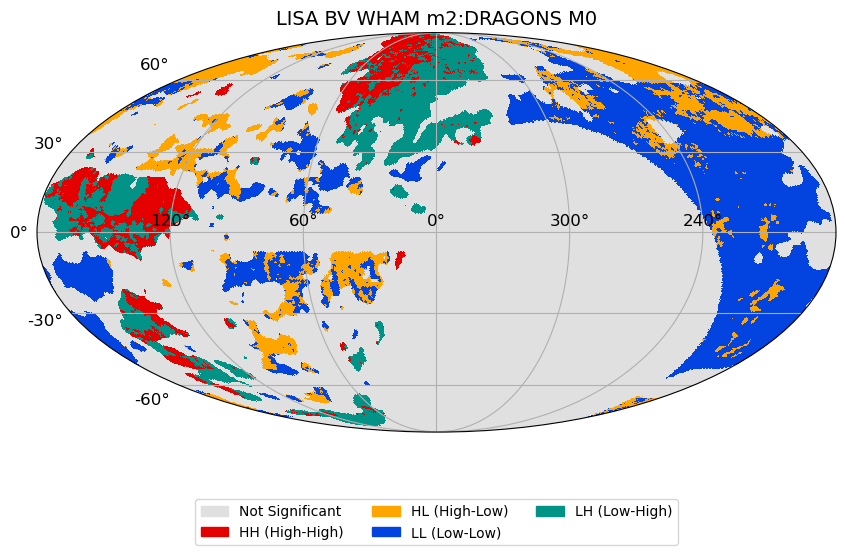

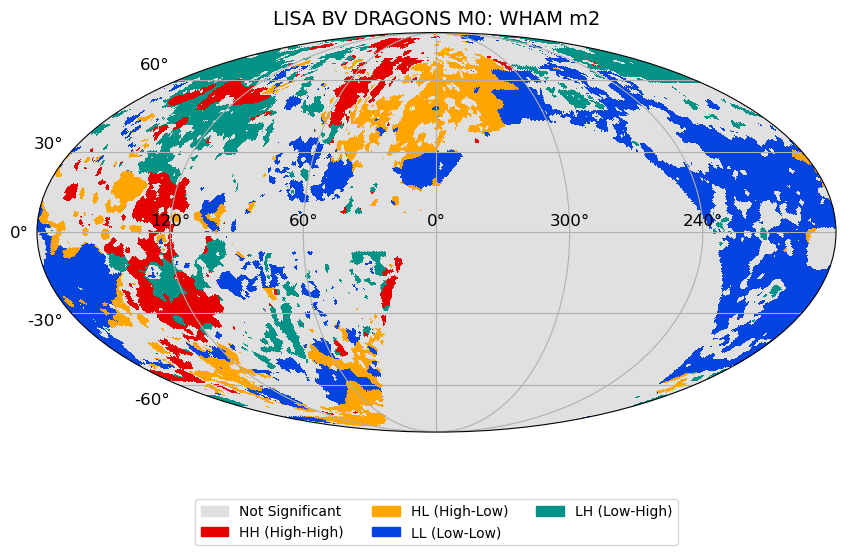

In [5]:
quadMap = analysis.build_lisa_bv_map(lisaBV,
                                    alpha = 0.05, 
                                    )
analysis.plot_lisa_bv_map(quadMap, title="LISA BV WHAM m2:DRAGONS M0", reverse=True)
#plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/LISABV_WHAMm2_DRAGONSM05perc", dpi=500, bbox_inches='tight')

quadMap2 = analysis.build_lisa_bv_map(lisaBV2,
                                     alpha = 0.05)
analysis.plot_lisa_bv_map(quadMap2, title="LISA BV DRAGONS M0: WHAM m2", reverse = True)
#plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/LISABV_DRAGONSM0_WHAMm2_10perc")


In [261]:
regions = analysis.extract_lisa_bv_regions(
    lisaBV, 
    alpha = 0.05, 
    quadrants=(1,2,3,4), 
    printRes=True
)

region   1  size=31934        type=mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 25116, 'HL': 6818})
center=(l=-144.14, b=  22.80)
----------------------------------------------------------------
region   0  size= 9879        type=mixed (dominant LH: {'HH': 2747, 'LH': 7132, 'LL': 0, 'HL': 0})
center=(l=  17.71, b=  56.99)
----------------------------------------------------------------
region  23  size= 6920        type=mixed (dominant HH: {'HH': 3746, 'LH': 3174, 'LL': 0, 'HL': 0})
center=(l= 145.95, b=   8.77)
----------------------------------------------------------------
region  36  size= 2833        type=mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 1948, 'HL': 885})
center=(l=  75.30, b= -16.76)
----------------------------------------------------------------
region  11  size= 2830        type=mixed (dominant HL: {'HH': 0, 'LH': 0, 'LL': 889, 'HL': 1941})
center=(l= 111.56, b=  26.87)
----------------------------------------------------------------
region  39  size= 2707        t

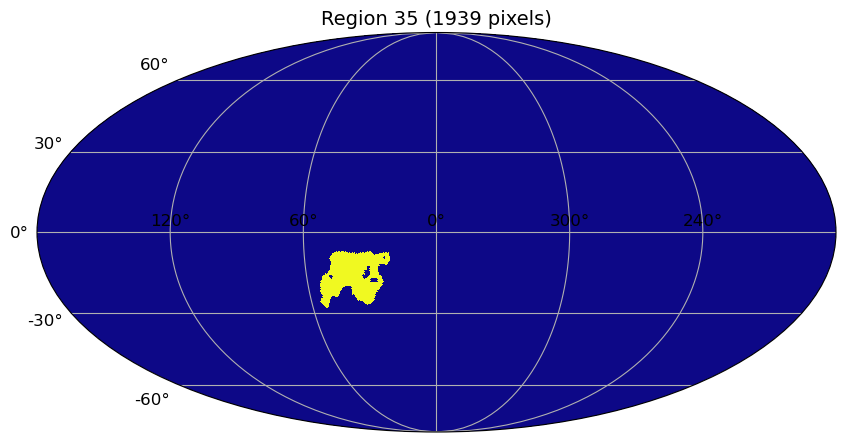

In [262]:
region = regions[6]
analysis.plot_region(region)

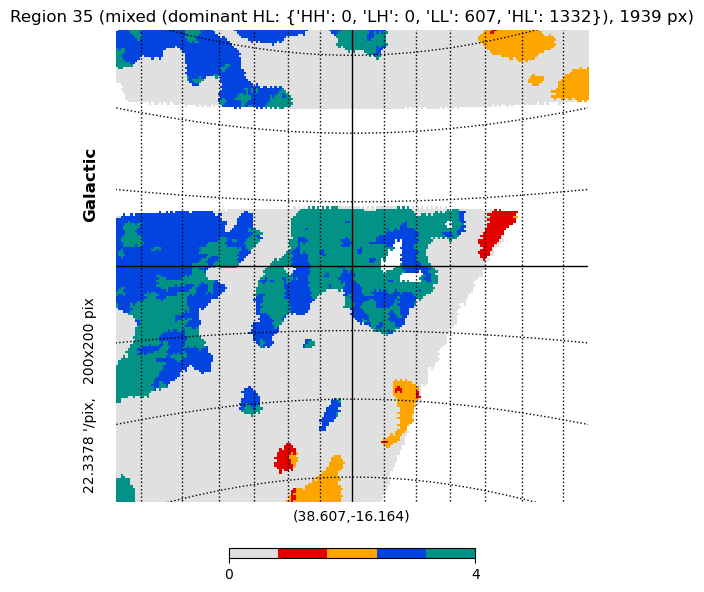

In [263]:
analysis.plot_region_cutout(quadMap, region, cmap=analysis.lisaCmap)
plt.savefig('/mnt/extra/ResearchSummer26/Code/figures/LISA_BV_WHAMm2_DRAGONS_zoom.png', dpi = 500, bbox_inches='tight')

# going to p

In [243]:
import healpy as hp 
import libpysal
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from AstroPySal import AstroPySal
from esda.moran import Moran, Moran_BV, Moran_Local, Moran_Local_BV
from matplotlib.colors import BoundaryNorm, ListedColormap
from astropy.coordinates import SkyCoord 
from spectral_cube import SpectralCube

In [345]:
fn1 = '/mnt/extra/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
fn2 = '/mnt/extra/ResearchSummer26/WHAM/wham-ss-DR1-v161116-170912-grid.fits'

dragCube = fits.getdata('/mnt/extra/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_CC_tot_Kgal.car.fits')
whamCube = fits.getdata(fn2)
dragHdr  = fits.getheader(fn1) 
whamHdr  = fits.getheader(fn2)

whamHdr

 [astropy.io.fits.verify]


SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

 [astropy.io.fits.verify]


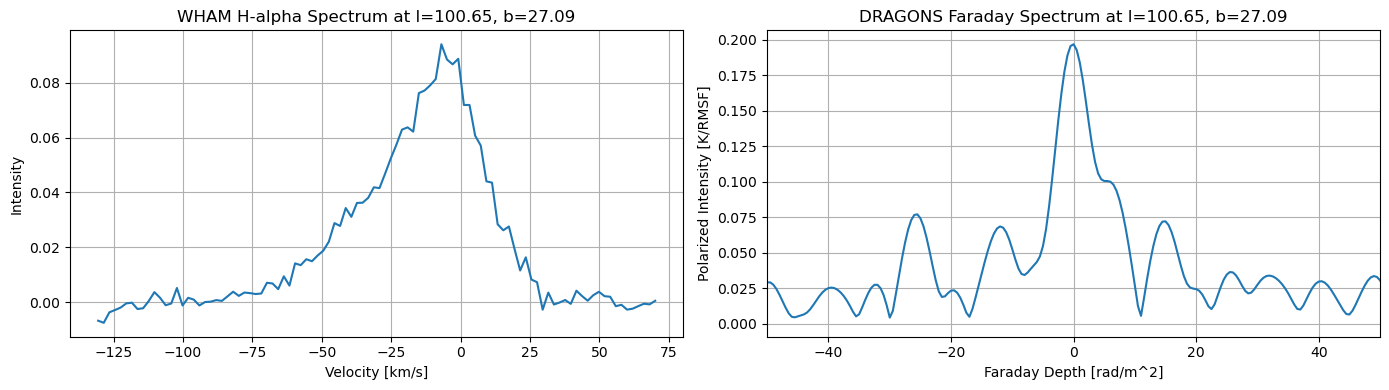

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

whamFile = fn2
dragonsFile = fn1

coord = SkyCoord(l=100.65 * u.deg, b=27.09 * u.deg, frame='galactic')


def extractWhamSpectrum(fitsFile, coord):
    fitsHeader = fits.getheader(fitsFile)
    fitsData = fits.getdata(fitsFile)

    wcsFull = WCS(fitsHeader)
    wcs2D = wcsFull.celestial
    xPix, yPix = wcs2D.world_to_pixel(coord)
    xIdx, yIdx = int(np.round(xPix)), int(np.round(yPix))

    if fitsData.ndim == 4:
        spectrum = fitsData[0, :, yIdx, xIdx]
        numPoints = fitsData.shape[1]
    elif fitsData.ndim == 3:
        spectrum = fitsData[:, yIdx, xIdx]
        numPoints = fitsData.shape[0]
    else:
        raise ValueError(f"Unexpected data shape: {fitsData.shape}")

    # velocity axis has a bogus CD3_3 in this file that overrides CDELT3
    # per the FITS standard, so build it directly from CRVAL3/CDELT3/CRPIX3
    crval3 = fitsHeader["CRVAL3"]
    cdelt3 = fitsHeader["CDELT3"]
    crpix3 = fitsHeader["CRPIX3"]
    pixelIndices = np.arange(numPoints)
    velocityValuesMeters = crval3 + (pixelIndices - (crpix3 - 1)) * cdelt3

    return velocityValuesMeters, spectrum, xIdx, yIdx


def extractDragonsSpectrum(fitsFile, coord):
    fitsHeader = fits.getheader(fitsFile)
    fitsData = fits.getdata(fitsFile)

    wcsFull = WCS(fitsHeader)
    wcs2D = wcsFull.celestial
    xPix, yPix = wcs2D.world_to_pixel(coord)
    xIdx, yIdx = int(np.round(xPix)), int(np.round(yPix))

    spectrum = fitsData[:, yIdx, xIdx]
    numPoints = fitsData.shape[0]

    pixelGrid = np.zeros((numPoints, 3))
    pixelGrid[:, 0] = xIdx
    pixelGrid[:, 1] = yIdx
    pixelGrid[:, 2] = np.arange(numPoints)

    worldGrid = wcsFull.all_pix2world(pixelGrid, 0)
    faradayDepthValues = worldGrid[:, 2]

    return faradayDepthValues, spectrum, xIdx, yIdx


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum)
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].set_xlim(-50,50)
plt.tight_layout()
plt.show()

 [astropy.io.fits.verify]


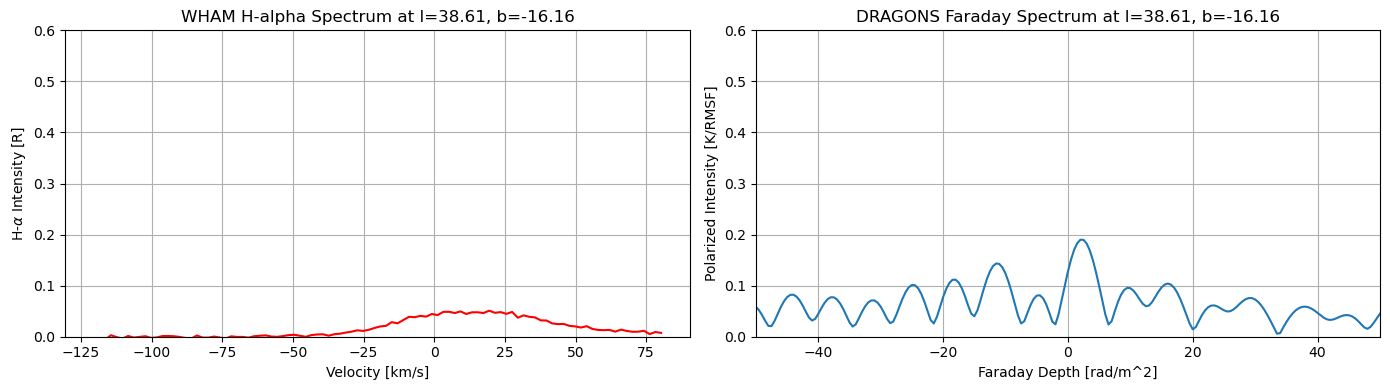

In [276]:
#=----------------------------------------------
#wham high dragons high 
#=--------------------------------------------
coord = SkyCoord(l=38.607 * u.deg, b=-16.164 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel(r"H-$\alpha$ Intensity [R]")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].set_ylim(0, 0.6)
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].set_xlim(-50,50)
axes[1].set_ylim(0, 0.6)
plt.tight_layout()
plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/near_plane_spectra.png", dpi = 500, bbox_inches='tight')
plt.show()

In [348]:
dragHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

 [astropy.io.fits.verify]


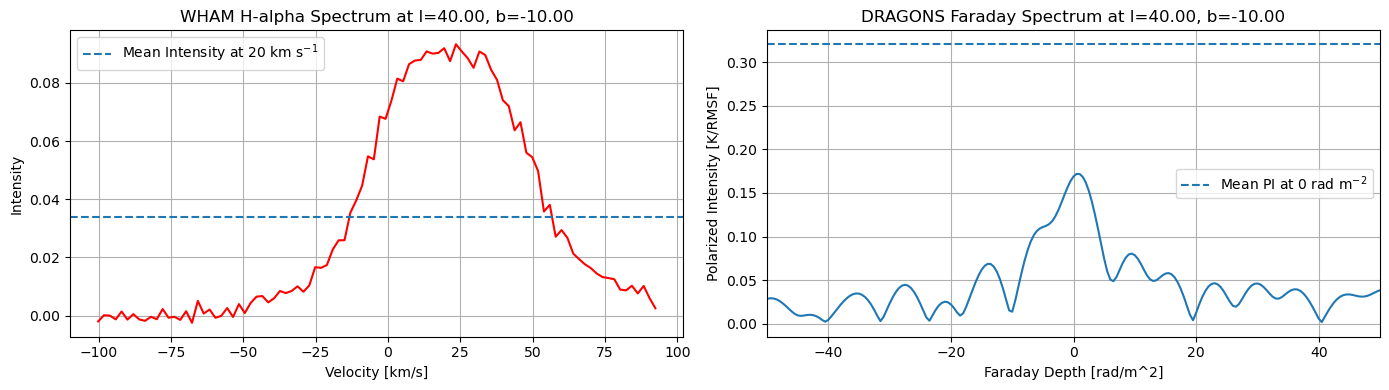

In [369]:
#=----------------------------------
#wham low dragons low 
#-----------------------------------

whamDatFits = fits.getdata(whamFile) 
dragDatFits = fits.getdata(dragonsFile)

coord = SkyCoord(l= 40 * u.deg, b= -10 * u.deg, frame='galactic')

peakIdx = np.argmax(velocityValuesKm)
peakX   = 

velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].axhline(y=np.nanmean(whamDatFits[96,:,:]), linestyle='--', linewidth=1.5, label=r'Mean Intensity at 20 km s$^{-1}$')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].axhline(y=np.nanmean(dragDatFits[403,:,:,]), linestyle='--', linewidth=1.5, label=r'Mean PI at 0 rad m$^{-2}$')
axes[1].set_xlim(-50,50)
axes[1].legend()
plt.tight_layout()
#plt.savefig('/mnt/extra/ResearchSummer26/Code/figures/spectra_all_the_bells_and_whistles.png', dpi=500, bbox_inches='tight')
plt.show()

 [astropy.io.fits.verify]


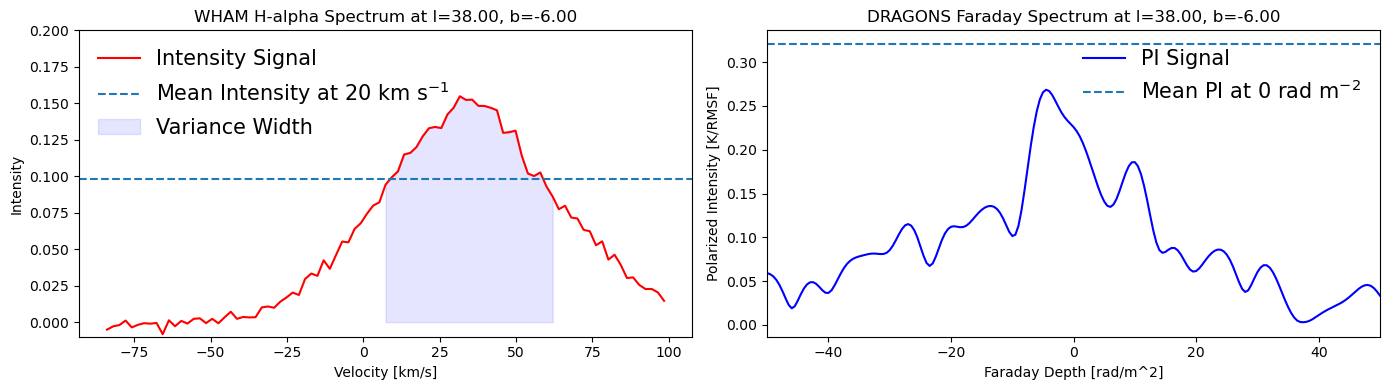

In [415]:


whamDatFits = fits.getdata(whamFile) 
dragDatFits = fits.getdata(dragonsFile)

coord = SkyCoord(l=38 * u.deg, b=-6* u.deg, frame='galactic')

velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)


mask = ~np.isnan(velocitySpectrum) & ~np.isnan(velocityValuesKm)
v_clean = velocityValuesKm[mask]
i_clean = velocitySpectrum[mask]

i_clean = np.clip(i_clean, 0, None) 

mean_v = np.sum(v_clean * i_clean) / np.sum(i_clean)

variance_v = np.sum(i_clean * (v_clean - mean_v)**2) / np.sum(i_clean)
sigma_v = np.sqrt(variance_v)  

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red', label="Intensity Signal")
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].axhline(y=np.nanmean(whamDatFits[83,:,:]), linestyle='--', linewidth=1.5, label=r'Mean Intensity at 20 km s$^{-1}$')
axes[0].set_ylim(-0.01,0.20)
#axes[0].axvline(mean_v, color='blue', linestyle='--', linewidth=1.5, label=f'Mean V: {mean_v:.1f} km/s')

# Plot Second Central Moment Boundaries (± 1 Sigma)
# axes[0].axvline(mean_v - sigma_v, color='blue', linestyle=':', linewidth=1.2, label=f'1$\sigma$ Spread ($\sigma$={sigma_v:.1f})')
# axes[0].axvline(mean_v + sigma_v, color='blue', linestyle=':', linewidth=1.2)

axes[0].fill_between(velocityValuesKm, velocitySpectrum, where=((velocityValuesKm >= mean_v - sigma_v) & (velocityValuesKm <= mean_v + sigma_v)), 
                     color='blue', alpha=0.1, label='Variance Width')

axes[0].legend(fontsize=15, frameon=False)

axes[1].plot(faradayDepthValues, faradaySpectrum, label="PI Signal", color='Blue')
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].axhline(y=np.nanmean(dragDatFits[403,:,:,]), linestyle='--', linewidth=1.5, label=r'Mean PI at 0 rad m$^{-2}$')
axes[1].set_xlim(-50,50)
axes[1].legend(fontsize=15, frameon=False)

plt.tight_layout()
plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/spectra_all_the_bells_and_whistles.png", dpi=500, bbox_inches='tight')
plt.show()


 [astropy.io.fits.verify]


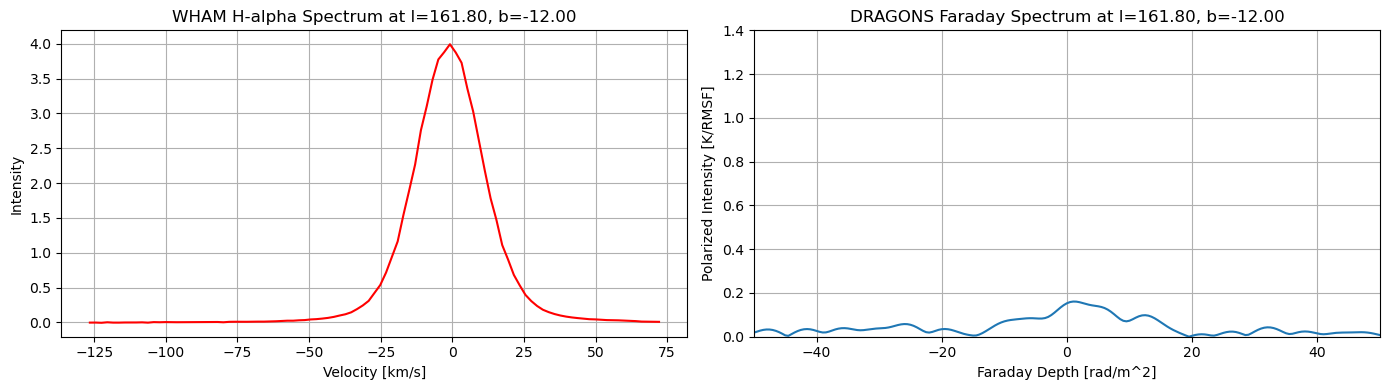

In [271]:
#=--------------------------------------------------
#wham High, DRAGONS LOW 
#=--------------------------------------------------
coord = SkyCoord(l=161.8 * u.deg, b=-12* u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum,color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].set_xlim(-50,50)
# axes[1].set_ylim(0, 1.4)
plt.tight_layout()
plt.show()

 [astropy.io.fits.verify]


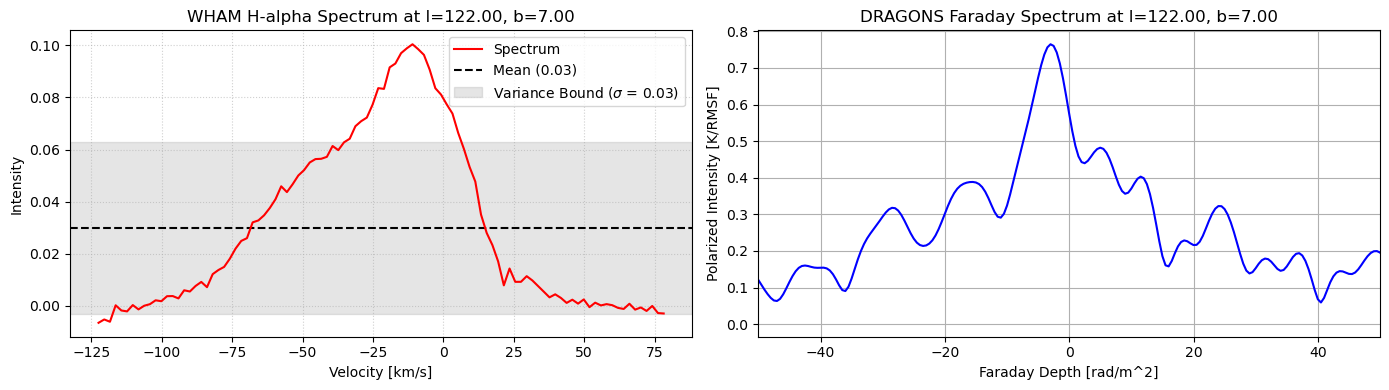

In [383]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

coord = SkyCoord(l=122 * u.deg, b=7 * u.deg, frame='galactic')

velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# =========================================================================
# LEFT AXIS: WHAM H-alpha Spectrum (With Global Variance Boundaries)
# =========================================================================
axes[0].plot(velocityValuesKm, velocitySpectrum, color='red', label='Spectrum', zorder=3)

mean_val = np.nanmean(velocitySpectrum)
var_val = np.nanvar(velocitySpectrum)
std_val = np.sqrt(var_val) 

axes[0].axhline(y=mean_val, color='black', linestyle='--', linewidth=1.5, 
                label=f'Mean ({mean_val:.2f})', zorder=2)

axes[0].axhspan(ymin=mean_val - std_val, ymax=mean_val + std_val, 
                color='gray', alpha=0.2, label=f'Variance Bound ($\sigma$ = {std_val:.2f})', zorder=1)

axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper right')

# =========================================================================
# RIGHT AXIS: DRAGONS Faraday Spectrum
# =========================================================================
axes[1].plot(faradayDepthValues, faradaySpectrum, color='blue')
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].set_xlim(-50, 50)

# Final formatting and rendering
plt.tight_layout()
plt.show()


 [astropy.io.fits.verify]


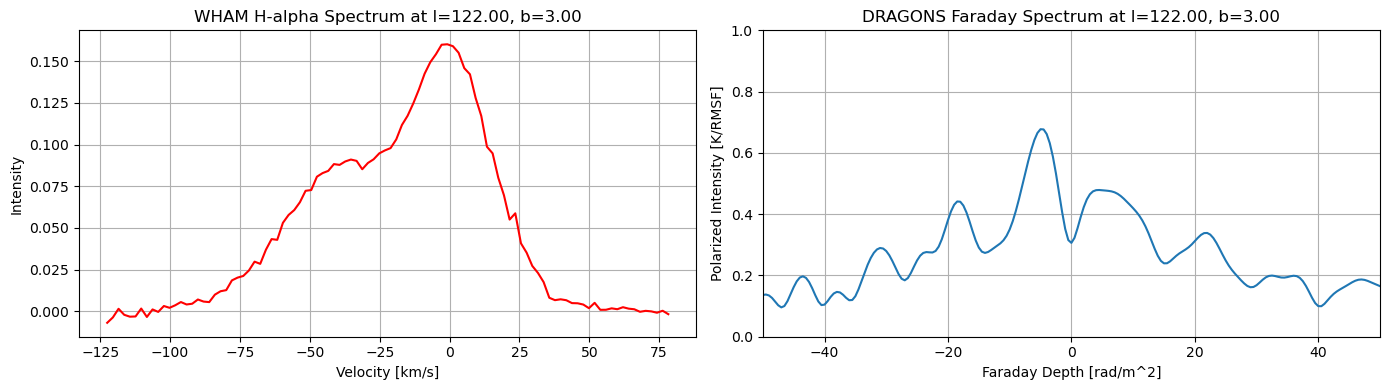

In [291]:
#=-----------------------------------------------
#wham low dragons high 
#=------------------------------------------------------
coord = SkyCoord(l=122 * u.deg, b=3 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color ='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)
axes[1].set_xlim(-50,50)
axes[1].set_ylim(0,1)
plt.tight_layout() 

plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/north_polar_spur_spectra.png", dpi = 500, bbox_inches='tight')
plt.show()

 [astropy.io.fits.verify]


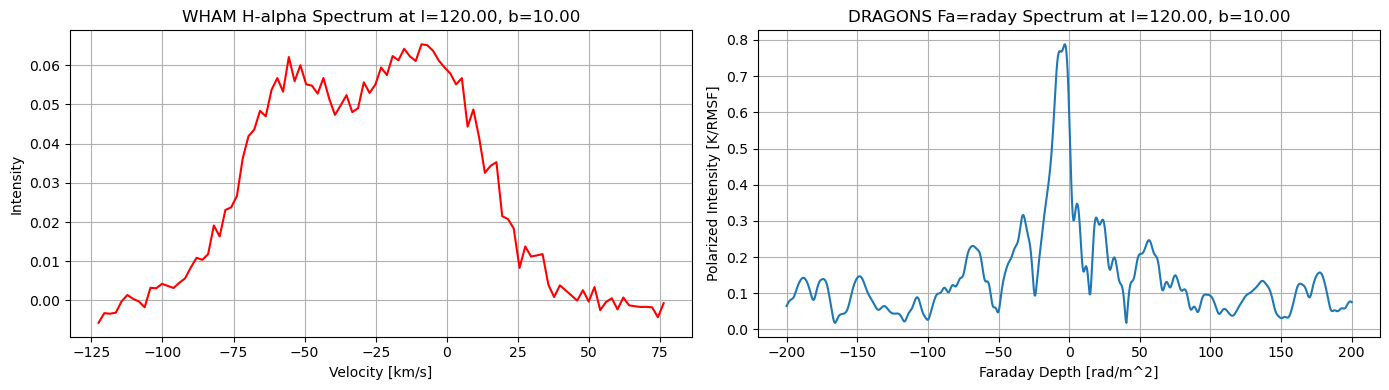

In [228]:
#now do it with the moment two stuff wham map 
#high wham moment 2, high dragons moment 0 
###########################################

coord = SkyCoord(l=120 * u.deg, b=10 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)
# axes[0].hline()

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Fa=raday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

 [astropy.io.fits.verify]


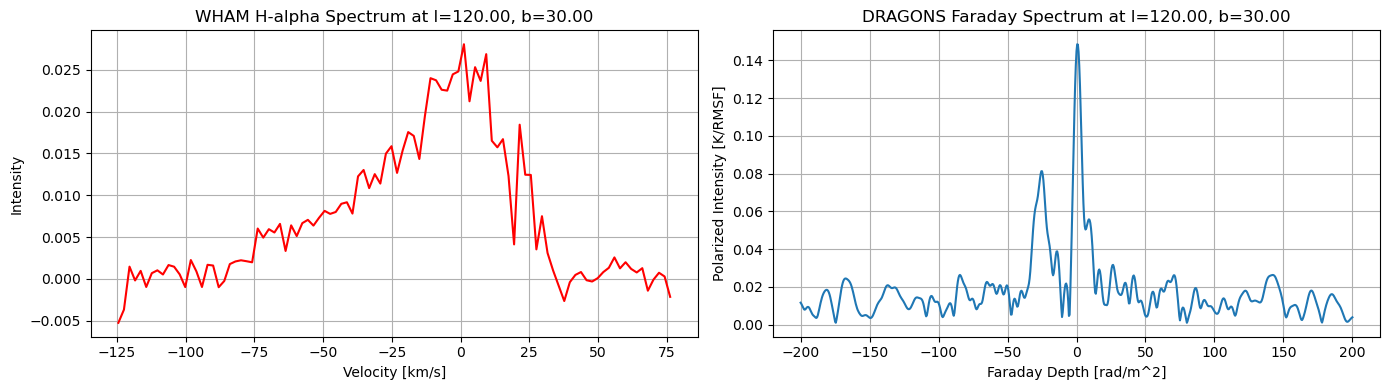

In [229]:
#####################################################
#high wham m2, low dragons M0 
######################################################

coord = SkyCoord(l=120 * u.deg, b=30 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

 [astropy.io.fits.verify]


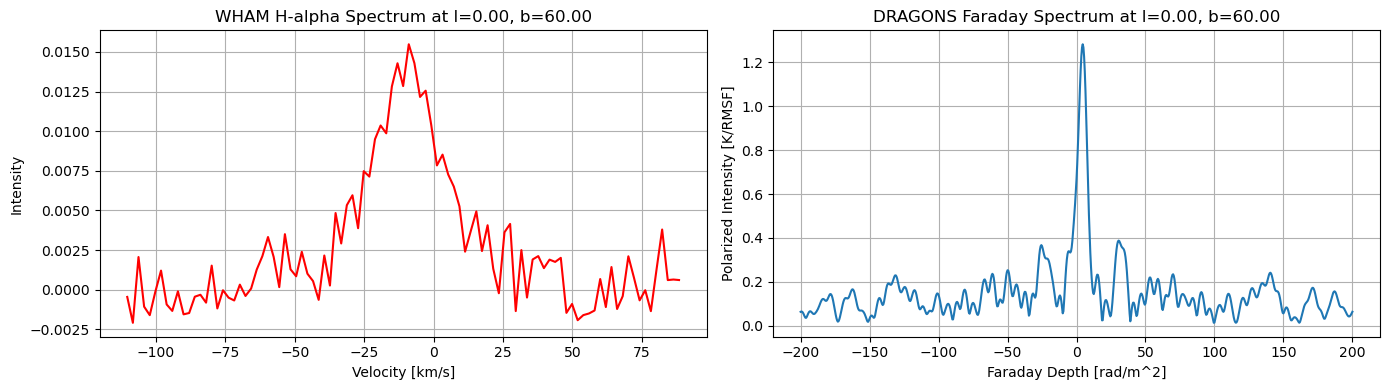

In [230]:
#low wham m2 and high dragons M0

coord = SkyCoord(l=0 * u.deg, b=60 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

 [astropy.io.fits.verify]


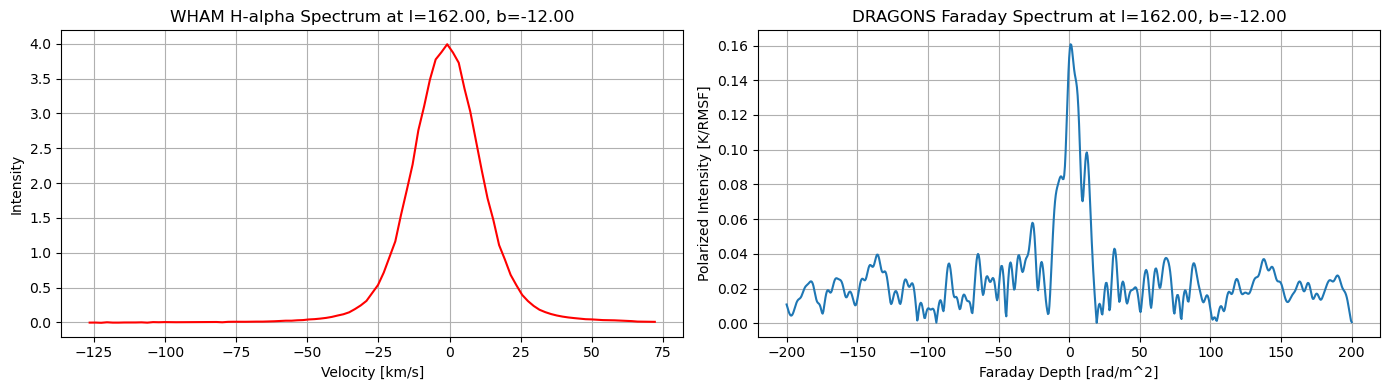

In [231]:
###############################
#low wham m2 and low dragons M0 
###############################
coord = SkyCoord(l=162 * u.deg, b=-12 * u.deg, frame='galactic')


velocityValuesMeters, velocitySpectrum, xIdxW, yIdxW = extractWhamSpectrum(whamFile, coord)
velocityValuesKm = velocityValuesMeters / 1000.0

faradayDepthValues, faradaySpectrum, xIdxD, yIdxD = extractDragonsSpectrum(dragonsFile, coord)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(velocityValuesKm, velocitySpectrum, color='red')
axes[0].set_xlabel("Velocity [km/s]")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"WHAM H-alpha Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[0].grid(True)

axes[1].plot(faradayDepthValues, faradaySpectrum)
axes[1].set_xlabel("Faraday Depth [rad/m^2]")
axes[1].set_ylabel("Polarized Intensity [K/RMSF]")
axes[1].set_title(f"DRAGONS Faraday Spectrum at l={coord.l.value:.2f}, b={coord.b.value:.2f}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
localMeanWham = analysis.compute_local_means(
    whamDatm2Masked, 
    radiusDeg=2.0,
)

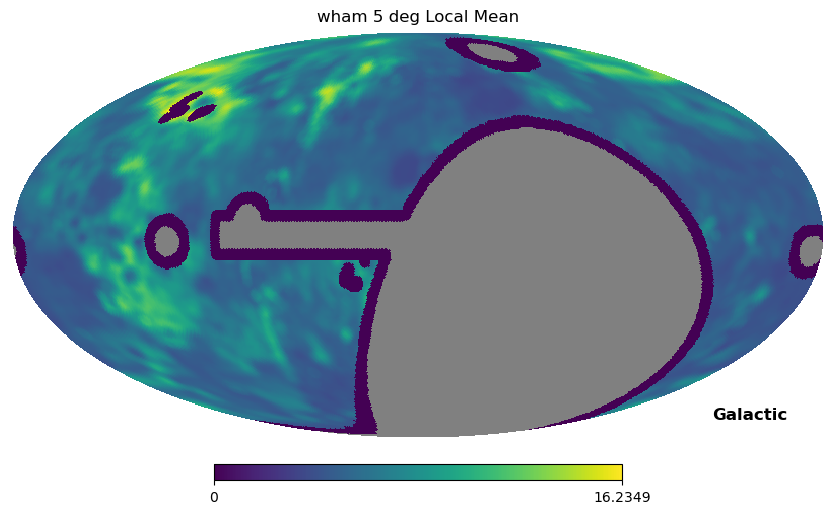

In [6]:
hp.mollview(
    localMeanWham, 
    coord='G',
    title="wham 5 deg Local Mean",
    min = 0
)

In [7]:
localMeanDrag = analysis.compute_local_means(
    dragDatM0Masked, 
    radiusDeg=2.0
)

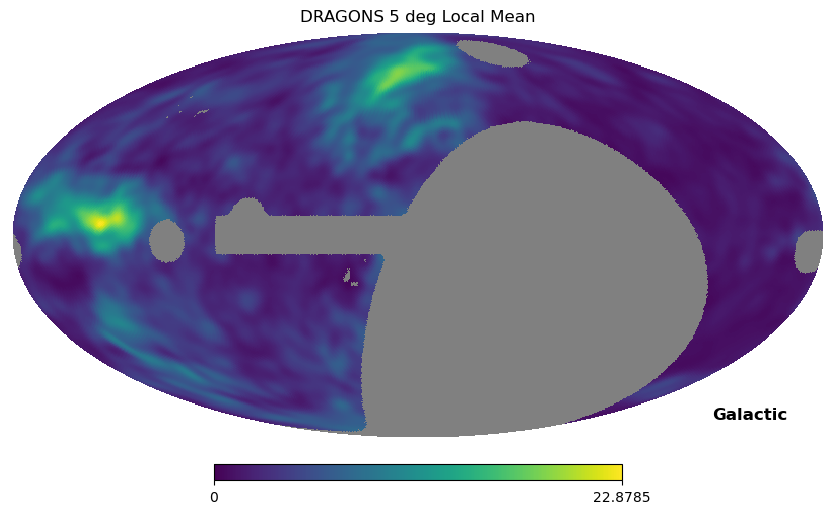

In [8]:
hp.mollview(localMeanDrag,
           coord='G',
           title='DRAGONS 5 deg Local Mean',
           min=0)

In [36]:
localLisa = analysis.lisa_bv_local_report(
    whamDatm2Masked,
    dragDatM0Masked,
    label="WHAM vs Dragons",
    radiusDeg=15.0,
    minValidFraction=0.1,
    permutations=999,
)

WHAM vs Dragons      significant= 50059/124311  HH= 5853  LH=15991  LL=20283  HL= 7932


In [37]:
(
    lisaLocal,
    localKeepIds,
    localMeanWham,
    localMeanDragons,
    whamResidual,
    dragonsResidual,
) = localLisa

In [38]:
localQuadMap = analysis.build_lisa_bv_map(
    lisaLocal, 
    localKeepIds, 
)

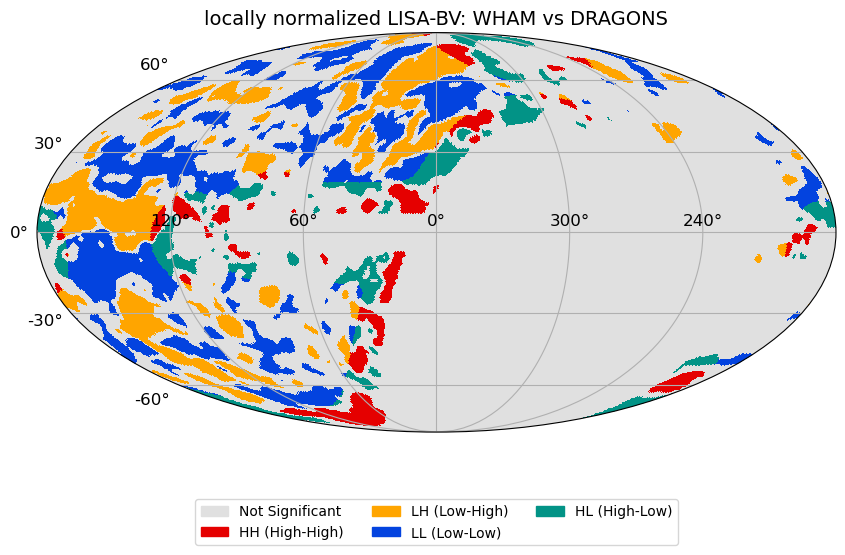

In [41]:
analysis.plot_lisa_bv_map(
    localQuadMap, 
    title="locally normalized LISA-BV: WHAM vs DRAGONS",
)